In [51]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

print(torch.__version__)
print(torch.cuda.is_available())   # Should print True
print(torch.cuda.get_device_name(0))

2.7.1+cu118
True
NVIDIA GeForce RTX 3060 Laptop GPU


In [52]:
df = pd.read_excel("data/all_iot_data_with_yield.xlsx")
df = df[(df['hour'] > 11) & (df['hour'] < 14)].copy()

# Filter NDVI between 0 and 1
df = df[(df['ndvi_predicted_nir_method'] >= 0) &
                      (df['ndvi_predicted_nir_method'] <= 1)]
# Filter yield greater than 0
df = df[(df['GYLD'] > 0)]

#df = df[(df['date'] >= '2024-05-13') & (df['date'] <= '2024-07-15')]


In [53]:
def create_lag_features(df, lag=3):
    df_sorted = df.sort_values(['plot_id', 'date'])
    lagged_data = []

    for plot_id, group in df_sorted.groupby('plot_id'):
        group = group.set_index('date')
        ndvi_series = group['ndvi_noir_rgb_method']
        lag_features = pd.concat(
            [ndvi_series.shift(i) for i in range(lag, 0, -1)],
            axis=1
        )
        lag_features.columns = [f'lag_{i}' for i in range(lag, 0, -1)]
        lag_features['GYLD'] = group['GYLD']
        lag_features['plot_id'] = plot_id
        lag_features = lag_features.dropna()
        lagged_data.append(lag_features)

    return pd.concat(lagged_data).reset_index()

lag = 3
df_lagged = create_lag_features(df, lag=lag)


In [54]:
feature_cols = [f'lag_{i}' for i in range(lag, 0, -1)]
target_col = 'GYLD'

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X = scaler_X.fit_transform(df_lagged[feature_cols].values)
y = df_lagged[[target_col]].values


In [55]:
class NDVIDataset(Dataset):
    def __init__(self, X, y):
        # reshape X to (samples, timesteps, features)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(2)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = NDVIDataset(X_train, y_train)
test_dataset = NDVIDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


In [56]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)  # out: (batch, seq_len, hidden)
        out = out[:, -1, :]    # take last timestep
        out = self.fc(out)
        return out

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LSTMModel(input_size=1, hidden_size=16).to(device)


In [57]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
train_losses = []
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {train_loss:.6f}')


Epoch 1/100, Loss: 131857352.128617
Epoch 2/100, Loss: 131623445.041801
Epoch 3/100, Loss: 131435172.698821
Epoch 4/100, Loss: 131253677.719185
Epoch 5/100, Loss: 131074804.227224
Epoch 6/100, Loss: 130897529.517685
Epoch 7/100, Loss: 130721274.512326
Epoch 8/100, Loss: 130545561.449089
Epoch 9/100, Loss: 130370223.468382
Epoch 10/100, Loss: 130195158.070740
Epoch 11/100, Loss: 130020352.960343
Epoch 12/100, Loss: 129845898.803859
Epoch 13/100, Loss: 129671717.067524
Epoch 14/100, Loss: 129497590.070740
Epoch 15/100, Loss: 129323600.274384
Epoch 16/100, Loss: 129149816.994641
Epoch 17/100, Loss: 128976087.451233
Epoch 18/100, Loss: 128802626.589496
Epoch 19/100, Loss: 128629307.181136
Epoch 20/100, Loss: 128456085.007503
Epoch 21/100, Loss: 128282868.201501
Epoch 22/100, Loss: 128109808.454448
Epoch 23/100, Loss: 127937060.047160
Epoch 24/100, Loss: 127764426.752412
Epoch 25/100, Loss: 127591837.007503
Epoch 26/100, Loss: 127419307.858521
Epoch 27/100, Loss: 127246901.230439
Epoch 28/1

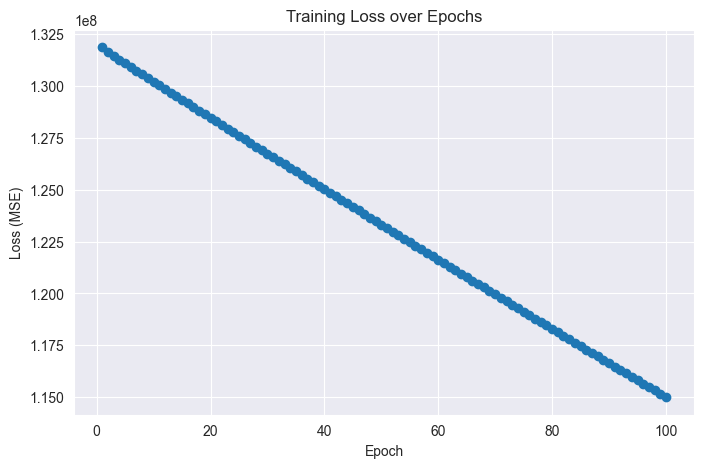

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

In [61]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_hat = model(X_batch)
        y_true.append(y_batch.numpy())
        y_pred.append(y_hat.cpu().numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)


# R²
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
print(f'Test R²: {r2:.4f}, Test MSE: {mse:.4f}')


Test R²: -18.2361, Test MSE: 117296112.0000
